In [7]:


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import precision_recall_curve,auc,classification_report
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [8]:
df = pd.read_csv(r"c:\Users\Naga Sai\Downloads\creditcard.csv")
df.dropna(inplace = True) #removes the null values from the dataframe..

print(df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [9]:
col_list=[]
for col in df.columns:
    if(col!='Class'):
        col_list.append(col)
x=df[col_list] #creates a new dataframe with all columns other than 'class' column

y=df['Class'] #new dataframe with only class column (we require for splitting of training and testing data in future!)
print(y)

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64


In [10]:
logReg=LogisticRegression()

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=234)
#splitting for training and testing data
smote=SMOTE(random_state=423)
x_train,y_train=smote.fit_resample(x_train,y_train) 

logReg.fit(x_train,y_train)

c:\Users\Naga Sai\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

accuracy(auc)=0.4858439473066981
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56855
           1       0.08      0.89      0.15       107

    accuracy                           0.98     56962
   macro avg       0.54      0.93      0.57     56962
weighted avg       1.00      0.98      0.99     56962



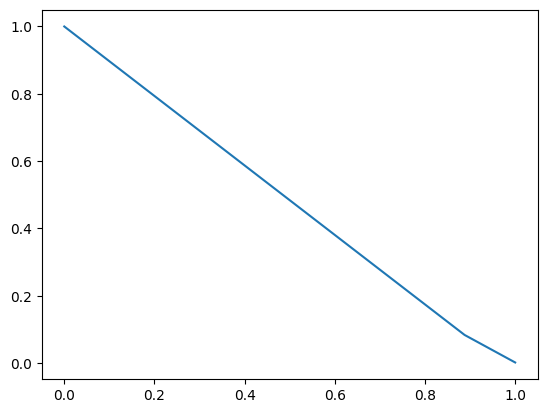

In [12]:
y_predict=logReg.predict(x_test) #predicting the output using the trained logReg model

#below 4 lines : calculating the performance report of the model
precision,recall,threshold=precision_recall_curve(y_test,y_predict)
print('accuracy(auc)={}'.format(auc(recall,precision)))
plt.plot(recall,precision)
print(classification_report(y_test,y_predict)) 